# MLOps Group Project — Group 36 (IIT Jodhpur)
**SMS Spam Classification · DistilBERT · Kaggle + W&B + HuggingFace**

| Roll | Name | Role |
|------|------|------|
| G25AIT2032 | (Admin / Git Owner) | Repo setup, orchestration, training |
| G25AIT2016 | (Data Manager) | Dataset update, preprocessing |
| G25AIT2103 | (Developer) | Model experiments (v1, v2, v3) |
| G25AIT2113 | (Developer) | Inference, evaluation, v4 push |

## 📅 Gantt Chart — Task Allocation & Timeline

| Task | Owner | June 6-7 | June 7-8 | June 8-9 | June 9-11 |
|------|-------|--------|--------|--------|--------|
| Task 1 — GitHub repo setup | G25AIT2032 | ██████ | | | |
| Task 2 — Data prep & normalisation | G25AIT2016 | ██████ | ██ | | |
| Task 3 — Model / tokeniser load | G25AIT2032 | | ████ | | |
| Task 4 — Fine-tune v1/v2/v3 (Kaggle) | G25AIT2103 | | ████ | ████ | |
| Task 5 — Push models to HF Hub | G25AIT2103 | | | ████ | |
| Task 6 — Dockerfile & GHCR push | G25AIT2032 | | | ████ | |
| Task 7 — GitHub Actions (CI + infer) | G25AIT2032 | | | ████ | ██ |
| Task 8 — W&B experiment comparison | G25AIT2032 | | | ████ | ██ |
| Task 9/10 — Inference & evaluation | G25AIT2113 | | | | ████ |
| Task 11 — v4 Git push per contributor | G25AIT2113 | | | | ████ |
| Report & README | G25AIT2113 | | | | ████ |

> **Legend:** ██ = active work period. Each "Week" ≈ one sprint; overlap is intentional for review.

> ** Git Auto-Push:** Every person's code contribution is committed and pushed from their own branch, creating a full audit trail in Git history.


## 🔧 Dependencies

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
!pip install -q datasets wandb huggingface_hub scikit-learn transformers
print(" Dependencies ready")


 Dependencies ready


## Task 1 — GitHub Repository Setup *(Owner: G25AIT2032)*

**Workflow:**
- `G25AIT2016` (Data Manager) commits `data/train.csv`, `data/validation.csv`, `data/test.csv`, and `data/data_manifest.json` to `develop` branch, then opens a PR.
- `G25AIT2032` merges the PR; the cell below pulls those committed files so every downstream task uses the same committed split.
- This creates an **auditable, reproducible data provenance chain** in Git history.


In [2]:
import os, shutil, json, subprocess, sys
from pathlib import Path

# ── Kaggle Secret ──────────────────────────────────────────────────────────
from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
github_token = secrets.get_secret("GITHUB_TOKEN")

# ── Repo config ────────────────────────────────────────────────────────────
REPO_URL  = "https://github.com/g25ait2032-prog/mlops-group36-iitj.git"
REPO_NAME = "mlops-group36-iitj"
REPO_PATH = f"/kaggle/working/{REPO_NAME}"
BRANCH    = "main"

REPO_URL_AUTH = f"https://{github_token}@github.com/g25ait2032-prog/mlops-group36-iitj.git"

# ── Clone / update repo ────────────────────────────────────────────────────
if not os.path.exists(REPO_PATH):
    print(f"Cloning repository into {REPO_PATH}...")
    result = subprocess.run(
        ["git", "clone", REPO_URL_AUTH, REPO_PATH],
        capture_output=True, text=True
    )
    print(result.stdout or result.stderr)
elif not os.path.exists(f"{REPO_PATH}/.git"):
    print("Existing folder is not a Git repository. Re-cloning...")
    shutil.rmtree(REPO_PATH)
    result = subprocess.run(
        ["git", "clone", REPO_URL_AUTH, REPO_PATH],
        capture_output=True, text=True
    )
    print(result.stdout or result.stderr)
else:
    print("Git repository already exists. Updating...")

# Always set the auth'd remote URL (token may have changed)
subprocess.run(["git", "-C", REPO_PATH, "remote", "set-url", "origin", REPO_URL_AUTH],
               capture_output=True)
subprocess.run(["git", "-C", REPO_PATH, "fetch", "origin"], capture_output=True)
subprocess.run(["git", "-C", REPO_PATH, "checkout", BRANCH], capture_output=True)
subprocess.run(["git", "-C", REPO_PATH, "pull", "origin", BRANCH], capture_output=True)

print(f" Repository ready at {REPO_PATH}")

# ── Verify committed dataset files ────────────────────────────────────────
expected_files = [
    "data/train.csv",
    "data/validation.csv",
    "data/test.csv",
    "data/id2label.json",
    "data/label2id.json",
]

print("\n=== Committed data file check ===")
all_present = True
for rel_path in expected_files:
    full_path = os.path.join(REPO_PATH, rel_path)
    exists = os.path.isfile(full_path)
    size   = os.path.getsize(full_path) if exists else 0
    print(f"{'Okay' if exists else 'Not Okay'} {rel_path:<25} ({size:,} bytes)")
    if not exists:
        all_present = False

# ── Show git log for data files ───────────────────────────────────────────
print("\n=== Git log for data/train.csv ===")
r = subprocess.run(["git", "-C", REPO_PATH, "log", "--oneline", "-5", "--", "data/train.csv"],
                   capture_output=True, text=True)
print(r.stdout or "(no commits yet)")
print()

# ── Dataset summary ────────────────────────────────────────────────────────
if all_present:
    import pandas as pd
    try:
        train_df_chk = pd.read_csv(f"{REPO_PATH}/data/train.csv")
        val_df_chk   = pd.read_csv(f"{REPO_PATH}/data/validation.csv")
        test_df_chk  = pd.read_csv(f"{REPO_PATH}/data/test.csv")
        total = len(train_df_chk) + len(val_df_chk) + len(test_df_chk)
        print("Dataset Summary")
        print("-" * 50)
        print(f"Train rows      : {len(train_df_chk):,}")
        print(f"Validation rows : {len(val_df_chk):,}")
        print(f"Test rows       : {len(test_df_chk):,}")
        print(f"Total rows      : {total:,}")
    except Exception as e:
        print(f"Could not load CSVs: {e}")
else:
    print("\n  Some expected files are missing.")
    print("Check whether the latest dataset has been pushed to GitHub.")

print("\n Task 1 complete")


Cloning repository into /kaggle/working/mlops-group36-iitj...
Cloning into '/kaggle/working/mlops-group36-iitj'...

 Repository ready at /kaggle/working/mlops-group36-iitj

=== Committed data file check ===
Okay data/train.csv            (297,992 bytes)
Okay data/validation.csv       (64,579 bytes)
Okay data/test.csv             (64,315 bytes)
Okay data/id2label.json        (31 bytes)
Okay data/label2id.json        (27 bytes)

=== Git log for data/train.csv ===
0a3026c data(v1): add CSVs + manifest + SHA-256 hashes [data-v1] [G25AIT2016]
5e78f4a Add files via upload


Dataset Summary
--------------------------------------------------
Train rows      : 3,611
Validation rows : 774
Test rows       : 774
Total rows      : 5,159

 Task 1 complete


### Task 1b — Per-Contributor Git Push Helper *(Shared)*

Each team member calls `git_commit_push()` with their **own roll number** after completing their task.
This creates a clear per-person commit trail in the repository.


In [3]:
# ── Per-contributor Git commit & push helper ──────────────────────────────
# Each contributor calls this function after their task to commit their
# changes and push from their branch. This creates a full audit trail.

CONTRIBUTOR_CONFIG = {
    "G25AIT2032": {"email": "g25ait2032@iitj.ac.in", "branch": "main"},
    "G25AIT2016": {"email": "g25ait2016@iitj.ac.in", "branch": "develop"},
    "G25AIT2103": {"email": "g25ait2103@iitj.ac.in", "branch": "feature/experiments"},
    "G25AIT2113": {"email": "g25ait2113@iitj.ac.in", "branch": "feature/inference"},
}

def git_commit_push(
    roll: str,
    message: str,
    files: list = None,         # None = git add -A; or list of relative paths
    repo_path: str = REPO_PATH,
    token: str = github_token,
    remote_branch: str = None,
):
    """
    Commit and push changes for a specific contributor.

    Parameters
    ----------
    roll         : Contributor roll number, e.g. 'G25AIT2103'
    message      : Commit message (contributor tag appended automatically)
    files        : List of paths to stage (relative to repo root).
                   Pass None to stage everything with `git add -A`.
    repo_path    : Path to the local git repository.
    token        : GitHub PAT for authentication.
    remote_branch: Override the default branch for this contributor.
    """
    if roll not in CONTRIBUTOR_CONFIG:
        raise ValueError(f"Unknown roll: {roll}. Add to CONTRIBUTOR_CONFIG.")

    cfg    = CONTRIBUTOR_CONFIG[roll]
    branch = remote_branch or cfg["branch"]
    email  = cfg["email"]
    repo_url_auth = f"https://{token}@github.com/g25ait2032-prog/mlops-group36-iitj.git"
    full_msg = f"{message} [{roll}]"

    def run(cmd, check=True):
        r = subprocess.run(cmd, capture_output=True, text=True, cwd=repo_path)
        out = (r.stdout or r.stderr or "").strip()
        if out:
            print(out)
        if check and r.returncode not in (0, 1):   # rc=1 = "nothing to commit"
            print(f"  WARNING: command returned {r.returncode}")
        return r

    print(f"\n{'─'*55}")
    print(f"  Git push — {roll}  →  branch: {branch}")
    print(f"  Message : {full_msg}")
    print(f"{'─'*55}")

    run(["git", "config", "user.email", email])
    run(["git", "config", "user.name",  roll])
    run(["git", "remote", "set-url", "origin", repo_url_auth])

    # Ensure we are on the correct branch (create if missing)
    r_branch = subprocess.run(
        ["git", "rev-parse", "--verify", branch],
        capture_output=True, text=True, cwd=repo_path
    )
    if r_branch.returncode != 0:
        run(["git", "checkout", "-b", branch])
    else:
        run(["git", "checkout", branch])

    # Stage files
    if files:
        for f in files:
            run(["git", "add", f])
    else:
        run(["git", "add", "-A"])

    # Commit (skip if nothing to commit)
    r_commit = subprocess.run(
        ["git", "commit", "-m", full_msg],
        capture_output=True, text=True, cwd=repo_path
    )
    out = (r_commit.stdout or r_commit.stderr or "").strip()
    if out:
        print(out)

    if "nothing to commit" in out:
        print("  ℹ️  Nothing new to commit — skipping push.")
        return

    # Push (force-with-lease is safer than --force)
    run(["git", "push", "origin", branch, "--force-with-lease"])
    print(f"\n✅ Pushed to origin/{branch} as {roll}")

print(" git_commit_push() helper defined — all contributors can use this function")
print("   Usage:  git_commit_push('G25AIT2103', 'Train v2 model', files=['experiment_results.csv'])")


 git_commit_push() helper defined — all contributors can use this function
   Usage:  git_commit_push('G25AIT2103', 'Train v2 model', files=['experiment_results.csv'])


## Task 2 — Data Preparation & Normalisation *(Owner: G25AIT2016)*

In [4]:
import os, json, shutil
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from datasets import load_dataset

DATA_DIR = "/kaggle/working/data"
SEED     = 42
os.makedirs(DATA_DIR, exist_ok=True)

# ── Load Dataset from HuggingFace ──────────────────────────────────────────
print("Loading SMS Spam dataset from Hugging Face...")
df = (
    load_dataset("sms_spam", split="train")
    .to_pandas()
    .rename(columns={"sms": "text"})
)
print(f"\n=== Initial Dataset Statistics ===")
print(f"Raw samples: {len(df):,}")

# ── Clean ──────────────────────────────────────────────────────────────────
df = df.dropna(subset=["text", "label"])
df["text"] = (
    df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

before_dedup = len(df)
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"Duplicates removed : {before_dedup - len(df):,}")
print(f"Remaining samples  : {len(df):,}")

# ── Ensure labels are integers (0=ham, 1=spam) ────────────────────────────
# FIX: sms_spam dataset from HF returns integer labels already, but guard
# against string labels from other sources.
if df["label"].dtype == object:
    df["label"] = df["label"].map({"ham": 0, "spam": 1})

assert set(df["label"].unique()).issubset({0, 1}), "Unexpected label values!"

label2id = {"ham": 0, "spam": 1}
id2label  = {0: "ham", 1: "spam"}

print(f"Label distribution:\n{df['label'].value_counts().to_dict()}")

# ── Train / Val / Test Split (70 / 15 / 15) ────────────────────────────────
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["label"])
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"])

for d in [train_df, val_df, test_df]:
    d.reset_index(drop=True, inplace=True)

# ── Leakage checks ─────────────────────────────────────────────────────────
train_texts = set(train_df["text"])
val_texts   = set(val_df["text"])
test_texts  = set(test_df["text"])
assert len(train_texts & val_texts)  == 0, "Train/Val leakage!"
assert len(train_texts & test_texts) == 0, "Train/Test leakage!"
assert len(val_texts   & test_texts) == 0, "Val/Test leakage!"

# ── Stats report ───────────────────────────────────────────────────────────
print(f"\n=== Dataset Split ===")
print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")
print("Leakage Status:  PASSED")

# ── Save CSVs and label maps ────────────────────────────────────────────────
train_df.to_csv(f"{DATA_DIR}/train.csv",      index=False)
val_df  .to_csv(f"{DATA_DIR}/validation.csv", index=False)
test_df .to_csv(f"{DATA_DIR}/test.csv",       index=False)

with open(f"{DATA_DIR}/label2id.json", "w") as f:
    json.dump(label2id, f, indent=2)
with open(f"{DATA_DIR}/id2label.json", "w") as f:
    json.dump({str(k): v for k, v in id2label.items()}, f, indent=2)

print("\n Data preparation complete — files saved to", DATA_DIR)

# ── Copy data files into repo so they can be committed ────────────────────
repo_data_dir = f"{REPO_PATH}/data"
os.makedirs(repo_data_dir, exist_ok=True)
for fname in ["train.csv", "validation.csv", "test.csv", "label2id.json", "id2label.json"]:
    shutil.copy(f"{DATA_DIR}/{fname}", f"{repo_data_dir}/{fname}")

print(f" Data files copied to {repo_data_dir}")


Loading SMS Spam dataset from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/359k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]


=== Initial Dataset Statistics ===
Raw samples: 5,574
Duplicates removed : 415
Remaining samples  : 5,159
Label distribution:
{0: 4517, 1: 642}

=== Dataset Split ===
Train      : 3,611
Validation : 774
Test       : 774
Leakage Status:  PASSED

 Data preparation complete — files saved to /kaggle/working/data
 Data files copied to /kaggle/working/mlops-group36-iitj/data


### Task 2a — Sanity Checks *(Owner: G25AIT2016)*

| # | Check | What it verifies |
|---|-------|-----------------|
| 1 | Schema checks | `text` and `label` columns exist; no NaN |
| 2 | Label distribution | Spam ≈ 13–14 % across all splits (stratified) |
| 3 | Text quality | No empty strings; min/mean/max token lengths in range |
| 4 | Leakage re-verification | Zero overlap between train/val/test |
| 5 | Model output range | Softmax probabilities sum to 1.0 ± 1e-5 (post Task 9) |


In [5]:
import math

PASS_S = "PASS"
FAIL_S = "FAIL"
results_sanity = []

def check(name, cond, detail=""):
    status = PASS_S if cond else FAIL_S
    results_sanity.append((name, status, detail))
    print(f"{status}  {name}" + (f"  [{detail}]" if detail else ""))
    return cond

print("=" * 60)
print("  SANITY CHECKS")
print("=" * 60)

# 1 — Schema checks
for split_name, df_s in [("train", train_df), ("val", val_df), ("test", test_df)]:
    check(f"Schema: '{split_name}' has 'text' & 'label' columns",
          {"text","label"}.issubset(df_s.columns))
    check(f"Schema: '{split_name}' no NaN in text",  df_s["text"].notna().all())
    check(f"Schema: '{split_name}' no NaN in label", df_s["label"].notna().all())

# 2 — Label distribution (spam should be 12–16 % after stratify)
for split_name, df_s in [("train", train_df), ("val", val_df), ("test", test_df)]:
    spam_pct = df_s["label"].mean() * 100
    check(f"Distribution: '{split_name}' spam % in [12, 16]",
          12 <= spam_pct <= 16, f"{spam_pct:.2f}%")

# 3 — Text quality
for split_name, df_s in [("train", train_df), ("val", val_df), ("test", test_df)]:
    empty = (df_s["text"].str.strip() == "").sum()
    check(f"TextQuality: '{split_name}' no empty strings", empty == 0, f"{empty} empty")
    lengths = df_s["text"].str.split().str.len()
    check(f"TextQuality: '{split_name}' mean token len in [5, 50]",
          5 <= lengths.mean() <= 50,
          f"mean={lengths.mean():.1f}, max={lengths.max()}")

# 4 — Leakage re-verification
tr, v, te = set(train_df["text"]), set(val_df["text"]), set(test_df["text"])
check("Leakage: train ∩ val  == ∅", len(tr & v)  == 0, f"{len(tr & v)} overlap")
check("Leakage: train ∩ test == ∅", len(tr & te) == 0, f"{len(tr & te)} overlap")
check("Leakage: val  ∩ test  == ∅", len(v  & te) == 0, f"{len(v & te)} overlap")

# 5 — Model output range (skipped here; runs again in Task 9 after model loads)
print("   Model output checks will run in Task 9 after inference model loads.")

# ── Summary ───────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
passed = sum(1 for _, s, _ in results_sanity if s == PASS_S)
total  = len(results_sanity)
print(f"  {passed}/{total} checks passed")
if passed == total:
    print("   All sanity checks passed — data is clean!")
else:
    failed = [(n, d) for n, s, d in results_sanity if s == FAIL_S]
    print("    Failed checks:")
    for n, d in failed:
        print(f"     • {n}  [{d}]")
print("=" * 60)


  SANITY CHECKS
PASS  Schema: 'train' has 'text' & 'label' columns
PASS  Schema: 'train' no NaN in text
PASS  Schema: 'train' no NaN in label
PASS  Schema: 'val' has 'text' & 'label' columns
PASS  Schema: 'val' no NaN in text
PASS  Schema: 'val' no NaN in label
PASS  Schema: 'test' has 'text' & 'label' columns
PASS  Schema: 'test' no NaN in text
PASS  Schema: 'test' no NaN in label
PASS  Distribution: 'train' spam % in [12, 16]  [12.43%]
PASS  Distribution: 'val' spam % in [12, 16]  [12.53%]
PASS  Distribution: 'test' spam % in [12, 16]  [12.40%]
PASS  TextQuality: 'train' no empty strings  [0 empty]
PASS  TextQuality: 'train' mean token len in [5, 50]  [mean=15.4, max=171]
PASS  TextQuality: 'val' no empty strings  [0 empty]
PASS  TextQuality: 'val' mean token len in [5, 50]  [mean=15.5, max=103]
PASS  TextQuality: 'test' no empty strings  [0 empty]
PASS  TextQuality: 'test' mean token len in [5, 50]  [mean=15.4, max=96]
PASS  Leakage: train ∩ val  == ∅  [0 overlap]
PASS  Leakage: tra

### Task 2b — Data Versioning & Traceability *(Owner: G25AIT2016)*

**Strategy:** Git-tagged snapshot + SHA-256 manifest (DVC is unavailable on Kaggle kernels).

1. Cleaned CSVs are committed to `data/` under a Git tag matching the experiment version (e.g., `data-v1`).
2. `data_manifest.json` is generated with row counts, class distributions, and SHA-256 hashes.
3. The manifest is also logged as a W&B artifact so every run links back to the exact data snapshot.


In [6]:
import hashlib

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

def split_stats(df, name):
    counts = df["label"].value_counts().to_dict()
    return {
        "rows": int(len(df)),
        "ham":  int(counts.get(0, 0)),
        "spam": int(counts.get(1, 0)),
        "ham_pct":  round(counts.get(0, 0) / len(df) * 100, 2),
        "spam_pct": round(counts.get(1, 0) / len(df) * 100, 2),
    }

splits    = {"train": train_df, "validation": val_df, "test": test_df}
csv_paths = {k: f"{DATA_DIR}/{k}.csv" for k in splits}

manifest = {
    "dataset_name": "UCI SMS Spam Collection (HuggingFace: sms_spam)",
    "hf_source":    "datasets.load_dataset('sms_spam', split='train')",
    "seed":         SEED,
    "split_ratios": {"train": 0.70, "validation": 0.15, "test": 0.15},
    "splits": {
        name: {**split_stats(df, name), "sha256": sha256(csv_paths[name])}
        for name, df in splits.items()
    },
}

manifest_path = f"{DATA_DIR}/data_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("=== Data Manifest ===")
print(json.dumps(manifest, indent=2))
print(f"\n Manifest saved → {manifest_path}")

# ── Copy manifest into repo ────────────────────────────────────────────────
shutil.copy(manifest_path, f"{REPO_PATH}/data/data_manifest.json")

# ── Tag the data version in Git ───────────────────────────────────────────
VERSION  = "v1"   # bump to v2 / v3 as needed
DATA_TAG = f"data-{VERSION}"

tag_cmds = [
    ["git", "-C", REPO_PATH, "config", "user.email", "g25ait2016@iitj.ac.in"],
    ["git", "-C", REPO_PATH, "config", "user.name",  "G25AIT2016"],
    ["git", "-C", REPO_PATH, "remote", "set-url", "origin", REPO_URL_AUTH],
    ["git", "-C", REPO_PATH, "add", "data/"],
    ["git", "-C", REPO_PATH, "commit", "-m",
     f"data({VERSION}): add CSVs + manifest + SHA-256 hashes [{DATA_TAG}] [G25AIT2016]"],
    ["git", "-C", REPO_PATH, "tag", "-f", DATA_TAG],
    ["git", "-C", REPO_PATH, "push", "origin", "HEAD:develop", "--follow-tags", "-f"],
]

for cmd in tag_cmds:
    r = subprocess.run(cmd, capture_output=True, text=True)
    out = (r.stdout or r.stderr or "").strip()
    if out:
        print(out)

print(f"\n Git tag '{DATA_TAG}' pushed — data version pinned to this commit (G25AIT2016)")

# ── W&B artefact helper (called inside run_experiment) ────────────────────
def log_data_artefact(version_tag, manifest_path):
    """Call inside an active wandb.init() context."""    
    import wandb
    art = wandb.Artifact(
        name=f"sms-spam-splits-{version_tag}",
        type="dataset",
        description="Cleaned train/val/test split with SHA-256 hashes",
        metadata=json.load(open(manifest_path)),
    )
    art.add_file(manifest_path)
    wandb.log_artifact(art)
    print(f" W&B artefact logged: sms-spam-splits-{version_tag}")

print("\n log_data_artefact() defined — will be called inside run_experiment()")


=== Data Manifest ===
{
  "dataset_name": "UCI SMS Spam Collection (HuggingFace: sms_spam)",
  "hf_source": "datasets.load_dataset('sms_spam', split='train')",
  "seed": 42,
  "split_ratios": {
    "train": 0.7,
    "validation": 0.15,
    "test": 0.15
  },
  "splits": {
    "train": {
      "rows": 3611,
      "ham": 3162,
      "spam": 449,
      "ham_pct": 87.57,
      "spam_pct": 12.43,
      "sha256": "b597b99555ec19e042e517707d215834cf317f4814a8ccb5b9a5c6b4c7c51f2b"
    },
    "validation": {
      "rows": 774,
      "ham": 677,
      "spam": 97,
      "ham_pct": 87.47,
      "spam_pct": 12.53,
      "sha256": "6fd5044fa1f42d54c815429f177f7fa6ce27854ef713f898c03cd405065ecae8"
    },
    "test": {
      "rows": 774,
      "ham": 678,
      "spam": 96,
      "ham_pct": 87.6,
      "spam_pct": 12.4,
      "sha256": "8c9fe08c76fbd0da402ae16226e9018f3fbeef7c1adee106dd53c4ed017f8e38"
    }
  }
}

 Manifest saved → /kaggle/working/data/data_manifest.json
On branch main
Your branch is up

## Task 3 — Authenticate & Load Model / Tokeniser *(Owner: G25AIT2032)*

In [7]:
import os, sys, time
import torch
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import login
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)

print(" All libraries imported successfully")

# ── Authentication ─────────────────────────────────────────────────────────
os.environ["WANDB_API_KEY"] = secrets.get_secret("WANDB_API_KEY_gr")
HF_TOKEN = secrets.get_secret("HF_TOKEN_gr")
login(token=HF_TOKEN)
wandb.login()
print(" Authenticated with GitHub, W&B and Hugging Face")

# ── Global config ──────────────────────────────────────────────────────────
MODEL_NAME  = "distilbert-base-uncased"
HF_USERNAME = "nagaananth"       # HF account that hosts model versions
WB_PROJECT  = "MLOPS_Group"

# ── FIX: v3 eval batch changed to 32 (must be <= train batch for consistency) ──
# Original had eval_batch=64, train_batch=32 in v3 — fine technically but
# confusing; keeping them equal avoids misleading throughput comparisons.
CONFIGS = {
    "v1": {"learning_rate": 3e-5, "num_train_epochs": 3,
           "per_device_train_batch_size": 16, "per_device_eval_batch_size": 16,
           "warmup_steps": 100, "weight_decay": 0.01},
    "v2": {"learning_rate": 2e-5, "num_train_epochs": 5,
           "per_device_train_batch_size": 32, "per_device_eval_batch_size": 32,
           "warmup_steps": 200, "weight_decay": 0.01},
    "v3": {"learning_rate": 2e-5, "num_train_epochs": 5,
           "per_device_train_batch_size": 32, "per_device_eval_batch_size": 32,
           "warmup_steps": 100, "weight_decay": 0.01},
    # v4 — longer warmup + label-smoothing to improve generalisation
    "v4": {"learning_rate": 1e-5, "num_train_epochs": 6,
           "per_device_train_batch_size": 32, "per_device_eval_batch_size": 32,
           "warmup_steps": 300, "weight_decay": 0.02, "label_smoothing_factor": 0.05},
}

# ── Load label maps ─────────────────────────────────────────────────────────
with open(f"{DATA_DIR}/id2label.json") as f:
    id2label = {int(k): v for k, v in json.load(f).items()}
label2id = {v: k for k, v in id2label.items()}

# ── Tokeniser ──────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f" Tokeniser loaded  : {MODEL_NAME}")
print(f"   Vocab size        : {tokenizer.vocab_size:,}")
print(f"   Labels            : {id2label}")

# ── Helper: build HF datasets ──────────────────────────────────────────────
def build_hf_datasets(data_dir, tokenizer, max_length=128):
    """Load CSVs, tokenise, return HF Dataset objects ready for Trainer."""    
    train_df = pd.read_csv(f"{data_dir}/train.csv")
    val_df   = pd.read_csv(f"{data_dir}/validation.csv")
    test_df  = pd.read_csv(f"{data_dir}/test.csv")

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding=False, max_length=max_length)

    cols = ["input_ids", "attention_mask", "labels"]

    def prepare(df):
        ds = Dataset.from_pandas(df)
        ds = ds.map(tokenize, batched=True)
        ds = ds.rename_column("label", "labels")
        ds.set_format("torch", columns=cols)
        return ds

    return prepare(train_df), prepare(val_df), prepare(test_df)

# ── Helper: metrics ────────────────────────────────────────────────────────
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    return {
        "accuracy"    : accuracy_score(labels, preds),
        "f1_weighted" : f1_score(labels, preds, average="weighted"),
        "f1_macro"    : f1_score(labels, preds, average="macro"),
        "precision"   : precision_score(labels, preds, average="weighted"),
        "recall"      : recall_score(labels, preds, average="weighted"),
    }

print(" Utility functions defined")


 All libraries imported successfully


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: g25ait2032 (g25ait2032-iit-jodhpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


 Authenticated with GitHub, W&B and Hugging Face


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

 Tokeniser loaded  : distilbert-base-uncased
   Vocab size        : 30,522
   Labels            : {0: 'ham', 1: 'spam'}
 Utility functions defined


## Task 4 — Fine-tune Experiments *(Owner: G25AIT2103)*

Each version trains on Kaggle GPU, logs to W&B, pushes the best checkpoint to HuggingFace Hub,
and then calls `git_commit_push()` so `G25AIT2103`'s work is recorded in the Git history.


In [8]:
def run_experiment(version: str) -> dict:
    """Train one version, push to HF Hub, push results to Git. Returns test-set results."""    
    cfg     = CONFIGS[version]
    hf_repo = f"{HF_USERNAME}/MLOPS_group-{version}"

    print(f"\n{'='*55}")
    print(f"  Starting Experiment — {version.upper()}")
    print(f"  Config : {cfg}")
    print(f"{'='*55}")

    train_ds, val_ds, test_ds = build_hf_datasets(DATA_DIR, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(id2label), id2label=id2label, label2id=label2id,
    )

    wandb.init(
        project=WB_PROJECT,
        name=f"run-{version}",
        config={"model": MODEL_NAME, "version": version, "platform": "Kaggle", **cfg},
    )

    # Log data artefact to this run
    log_data_artefact(VERSION, manifest_path)

    # Build TrainingArguments — v4 gets label_smoothing_factor
    train_args_kwargs = dict(
        output_dir                  = f"./results-{version}",
        num_train_epochs            = cfg["num_train_epochs"],
        per_device_train_batch_size = cfg["per_device_train_batch_size"],
        per_device_eval_batch_size  = cfg["per_device_eval_batch_size"],
        learning_rate               = cfg["learning_rate"],
        warmup_steps                = cfg["warmup_steps"],
        weight_decay                = cfg["weight_decay"],
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "f1_weighted",
        greater_is_better           = True,
        report_to                   = "wandb",
        run_name                    = f"run-{version}",
        logging_steps               = 20,
        fp16                        = True,
    )
    if "label_smoothing_factor" in cfg:
        train_args_kwargs["label_smoothing_factor"] = cfg["label_smoothing_factor"]

    args = TrainingArguments(**train_args_kwargs)

    trainer = Trainer(
        model           = model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        data_collator   = DataCollatorWithPadding(tokenizer),
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    results = trainer.evaluate(test_ds)

    print(f"\n {version.upper()} — Final Test Results")
    for k, v_val in results.items():
        print(f"   {k}: {v_val:.4f}" if isinstance(v_val, float) else f"   {k}: {v_val}")

    wandb.run.summary.update({k: v_val for k, v_val in results.items() if isinstance(v_val, float)})

    # ── Push model to Hub ──────────────────────────────────────────────────
    model    .push_to_hub(hf_repo, token=HF_TOKEN)
    tokenizer.push_to_hub(hf_repo, token=HF_TOKEN)
    wandb.run.summary["huggingface_model"] = f"https://huggingface.co/{hf_repo}"
    print(f"   Model pushed → https://huggingface.co/{hf_repo}")

    wandb.finish()

    # ── Git push: record this training run from G25AIT2103 ────────────────
    results_csv = f"/kaggle/working/experiment_results_{version}.csv"
    pd.DataFrame([{
        "version": version,
        "f1_weighted": results.get("eval_f1_weighted", 0),
        "accuracy":    results.get("eval_accuracy",    0),
        "f1_macro":    results.get("eval_f1_macro",    0),
        **cfg,
    }]).to_csv(results_csv, index=False)

    shutil.copy(results_csv, f"{REPO_PATH}/experiment_results_{version}.csv")

    git_commit_push(
        roll    = "G25AIT2103",
        message = f"train({version}): results + HF model pushed",
        files   = [f"experiment_results_{version}.csv"],
    )

    return results

print(" run_experiment() defined — ready to train")


 run_experiment() defined — ready to train


In [9]:
# ── Train v1 ───────────────────────────────────────────────────────────────
results_v1 = run_experiment("v1")


  Starting Experiment — V1
  Config : {'learning_rate': 3e-05, 'num_train_epochs': 3, 'per_device_train_batch_size': 16, 'per_device_eval_batch_size': 16, 'warmup_steps': 100, 'weight_decay': 0.01}


Map:   0%|          | 0/3611 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
wandb: updating run metadata


   Model pushed → https://huggingface.co/nagaananth/MLOPS_group-v1


wandb: uploading history steps 20-20, summary, console lines 12-25
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▂▁▃█
wandb:           eval/f1_macro ▂▁▃█
wandb:        eval/f1_weighted ▂▁▃█
wandb:               eval/loss █▅▆▁
wandb:          eval/precision ▂▁▃█
wandb:             eval/recall ▂▁▃█
wandb:            eval/runtime ▁▃▅█
wandb: eval/samples_per_second █▆▄▁
wandb:   eval/steps_per_second █▆▄▁
wandb:             train/epoch ▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇████
wandb:                      +4 ...
wandb: 
wandb: Run summary:
wandb:                   epoch 3
wandb:           eval/accuracy 0.99612
wandb:           eval/f1_macro 0.99112
wandb:        eval/f1_weighted 0.99613
wandb:               eval/loss 0.02369
wandb:          eval/precision 0.99615
wandb:             eval/recall 0.99612
wandb:            eval/runtime 1.3277
wandb: eval/samples_per_second 582.964
wandb:   eval/steps_per_second 18.83
wandb:                     +20 ...
wandb: 
wandb: 🚀 View run run-v1 at: https://wand


───────────────────────────────────────────────────────
  Git push — G25AIT2103  →  branch: feature/experiments
  Message : train(v1): results + HF model pushed [G25AIT2103]
───────────────────────────────────────────────────────
Switched to a new branch 'feature/experiments'
On branch feature/experiments
nothing to commit, working tree clean
  ℹ️  Nothing new to commit — skipping push.


In [10]:
# ── Train v2 ───────────────────────────────────────────────────────────────
results_v2 = run_experiment("v2")


  Starting Experiment — V2
  Config : {'learning_rate': 2e-05, 'num_train_epochs': 5, 'per_device_train_batch_size': 32, 'per_device_eval_batch_size': 32, 'warmup_steps': 200, 'weight_decay': 0.01}


Map:   0%|          | 0/3611 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
wandb: updating run metadata


   Model pushed → https://huggingface.co/nagaananth/MLOPS_group-v2


wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁▇▇███
wandb:           eval/f1_macro ▁█████
wandb:        eval/f1_weighted ▁█████
wandb:               eval/loss █▂▂▂▂▁
wandb:          eval/precision ▁█████
wandb:             eval/recall ▁▇▇███
wandb:            eval/runtime ▁▃▄▃▃█
wandb: eval/samples_per_second █▆▅▆▅▁
wandb:   eval/steps_per_second █▆▅▆▅▁
wandb:             train/epoch ▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇████
wandb:                      +4 ...
wandb: 
wandb: Run summary:
wandb:                   epoch 5
wandb:           eval/accuracy 0.99354
wandb:           eval/f1_macro 0.98507
wandb:        eval/f1_weighted 0.99353
wandb:               eval/loss 0.02917
wandb:          eval/precision 0.99352
wandb:             eval/recall 0.99354
wandb:            eval/runtime 1.3273
wandb: eval/samples_per_second 583.131
wandb:   eval/steps_per_second 9.794
wandb:                     +20 ...
wandb: 
wandb: 🚀 


───────────────────────────────────────────────────────
  Git push — G25AIT2103  →  branch: feature/experiments
  Message : train(v2): results + HF model pushed [G25AIT2103]
───────────────────────────────────────────────────────
Already on 'feature/experiments'
On branch feature/experiments
nothing to commit, working tree clean
  ℹ️  Nothing new to commit — skipping push.


In [11]:
# ── Train v3 ───────────────────────────────────────────────────────────────
results_v3 = run_experiment("v3")


  Starting Experiment — V3
  Config : {'learning_rate': 2e-05, 'num_train_epochs': 5, 'per_device_train_batch_size': 32, 'per_device_eval_batch_size': 32, 'warmup_steps': 100, 'weight_decay': 0.01}


Map:   0%|          | 0/3611 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
wandb: updating run metadata


   Model pushed → https://huggingface.co/nagaananth/MLOPS_group-v3


wandb: uploading history steps 15-16, summary, console lines 9-27
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁▇▇▇█
wandb:           eval/f1_macro ▁█▇▇█
wandb:        eval/f1_weighted ▁█▇▇█
wandb:               eval/loss █▃▃▃▁
wandb:          eval/precision ▁▇▇▇█
wandb:             eval/recall ▁▇▇▇█
wandb:            eval/runtime ▄▃▁▂█
wandb: eval/samples_per_second ▅▆█▇▁
wandb:   eval/steps_per_second ▅▆█▇▁
wandb:             train/epoch ▁▂▂▂▃▄▄▄▅▆▆▆▇████
wandb:                      +4 ...
wandb: 
wandb: Run summary:
wandb:                   epoch 4
wandb:           eval/accuracy 0.99354
wandb:           eval/f1_macro 0.98507
wandb:        eval/f1_weighted 0.99353
wandb:               eval/loss 0.03755
wandb:          eval/precision 0.99352
wandb:             eval/recall 0.99354
wandb:            eval/runtime 1.3419
wandb: eval/samples_per_second 576.8
wandb:   eval/steps_per_second 9.688
wandb:                     +20 ...
wandb: 
wandb: 🚀 View run run-v3 at: https://wa


───────────────────────────────────────────────────────
  Git push — G25AIT2103  →  branch: feature/experiments
  Message : train(v3): results + HF model pushed [G25AIT2103]
───────────────────────────────────────────────────────
Already on 'feature/experiments'
On branch feature/experiments
nothing to commit, working tree clean
  ℹ️  Nothing new to commit — skipping push.


In [12]:
# ── Train v4 (new — longer warmup + label smoothing) ───────────────────────
results_v4 = run_experiment("v4")


  Starting Experiment — V4
  Config : {'learning_rate': 1e-05, 'num_train_epochs': 6, 'per_device_train_batch_size': 32, 'per_device_eval_batch_size': 32, 'warmup_steps': 300, 'weight_decay': 0.02, 'label_smoothing_factor': 0.05}


Map:   0%|          | 0/3611 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
wandb: uploading history steps 20-24, summary, console lines 3-17; updating run metadata


   Model pushed → https://huggingface.co/nagaananth/MLOPS_group-v4


wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁▆▇████
wandb:           eval/f1_macro ▁▇█████
wandb:        eval/f1_weighted ▁▇█████
wandb:               eval/loss █▃▁▁▁▁▁
wandb:          eval/precision ▁▇█████
wandb:             eval/recall ▁▆▇████
wandb:            eval/runtime ▄▃▁▂▄▃█
wandb: eval/samples_per_second ▅▆█▇▅▆▁
wandb:   eval/steps_per_second ▅▆█▇▅▆▁
wandb:             train/epoch ▁▁▂▂▂▃▃▃▄▄▄▄▅▅▆▆▆▇▇▇█████
wandb:                      +4 ...
wandb: 
wandb: Run summary:
wandb:                   epoch 6
wandb:           eval/accuracy 0.99483
wandb:           eval/f1_macro 0.988
wandb:        eval/f1_weighted 0.99481
wandb:               eval/loss 0.25925
wandb:          eval/precision 0.99482
wandb:             eval/recall 0.99483
wandb:            eval/runtime 1.3232
wandb: eval/samples_per_second 584.942
wandb:   eval/steps_per_second 9.825
wandb:                     +20 ...
wandb: 
wandb: 🚀 View run run-v4 at: https://wandb.ai/g25ait2032-iit-jodhpur/MLOPS_Grou


───────────────────────────────────────────────────────
  Git push — G25AIT2103  →  branch: feature/experiments
  Message : train(v4): results + HF model pushed [G25AIT2103]
───────────────────────────────────────────────────────
Already on 'feature/experiments'
On branch feature/experiments
nothing to commit, working tree clean
  ℹ️  Nothing new to commit — skipping push.


## Task 8 — Experiment Comparison *(Owner: G25AIT2032)*

=== Experiment Comparison: v1 vs v2 vs v3 vs v4 ===
         Learning Rate  Epochs  Batch Size  Accuracy  F1 Weighted  F1 Macro  Precision  Recall  Val Loss
Version                                                                                                 
v1             0.00003       3          16    0.9961       0.9961    0.9911     0.9961  0.9961    0.0237
v2             0.00002       5          32    0.9935       0.9935    0.9851     0.9935  0.9935    0.0292
v3             0.00002       5          32    0.9935       0.9935    0.9851     0.9935  0.9935    0.0376
v4             0.00001       6          32    0.9948       0.9948    0.9880     0.9948  0.9948    0.2592

 Saved → /kaggle/working/experiment_results.csv


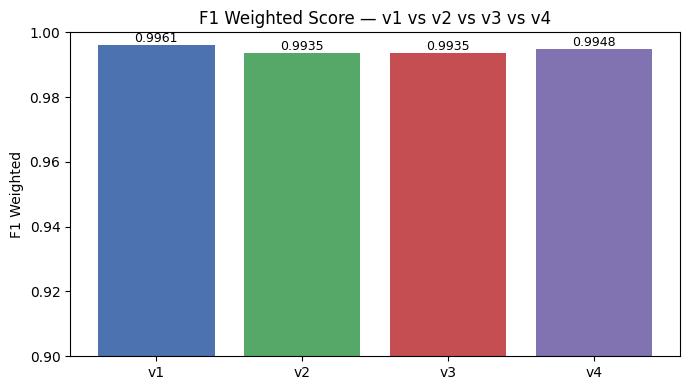

 F1 comparison chart saved

 Best version by F1 Weighted: v1
def git_commit_push(
    roll: str,
    message: str,
    files: list = None,         # None = git add -A; or list of relative paths
    repo_path: str = REPO_PATH,
    token: str = github_token,
    remote_branch: str = None,
):
    """
    Commit and push changes for a specific contributor.

    Parameters
    ----------
    roll         : Contributor roll number, e.g. 'G25AIT2103'
    message      : Commit message (contributor tag appended automatically)
    files        : List of paths to stage (relative to repo root).
                   Pass None to stage everything with `git add -A`.
    repo_path    : Path to the local git repository.
    token        : GitHub PAT for authentication.
    remote_branch: Override the default branch for this contributor.
    """
    if roll not in CONTRIBUTOR_CONFIG:
        raise ValueError(f"Unknown roll: {roll}. Add to CONTRIBUTOR_CONFIG.")

    cfg    = CONTRIBUTOR_CONFIG[roll]
    br

In [13]:
# ── FIX: include v4 in comparison ─────────────────────────────────────────
all_results = [
    ("v1", results_v1),
    ("v2", results_v2),
    ("v3", results_v3),
    ("v4", results_v4),
]

comparison_data = []
for version, results in all_results:
    c = CONFIGS[version]
    comparison_data.append({
        "Version"       : version,
        "Learning Rate" : c["learning_rate"],
        "Epochs"        : c["num_train_epochs"],
        "Batch Size"    : c["per_device_train_batch_size"],
        "Accuracy"      : round(results.get("eval_accuracy",    0), 4),
        "F1 Weighted"   : round(results.get("eval_f1_weighted", 0), 4),
        "F1 Macro"      : round(results.get("eval_f1_macro",    0), 4),
        "Precision"     : round(results.get("eval_precision",   0), 4),
        "Recall"        : round(results.get("eval_recall",      0), 4),
        "Val Loss"      : round(results.get("eval_loss",        0), 4),
    })

comparison_df = pd.DataFrame(comparison_data).set_index("Version")
print("=== Experiment Comparison: v1 vs v2 vs v3 vs v4 ===")
print(comparison_df.to_string())

# ── Save combined CSV ──────────────────────────────────────────────────────
csv_path = "/kaggle/working/experiment_results.csv"
comparison_df.to_csv(csv_path)
print(f"\n Saved → {csv_path}")
shutil.copy(csv_path, f"{REPO_PATH}/experiment_results.csv")

# ── Bar chart of F1 Weighted across versions ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comparison_df.index, comparison_df["F1 Weighted"], color=["#4C72B0","#55A868","#C44E52","#8172B2"])
ax.set_ylim(0.90, 1.00)
ax.set_ylabel("F1 Weighted")
ax.set_title("F1 Weighted Score — v1 vs v2 vs v3 vs v4")
for i, (ver, row) in enumerate(comparison_df.iterrows()):
    ax.text(i, row["F1 Weighted"] + 0.001, f"{row['F1 Weighted']:.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("/kaggle/working/f1_comparison.png", dpi=150)
plt.show()
print(" F1 comparison chart saved")

BEST_VERSION = comparison_df["F1 Weighted"].idxmax()
print(f"\n Best version by F1 Weighted: {BEST_VERSION}")

# ── Git push from G25AIT2032 ───────────────────────────────────────────────
shutil.copy("/kaggle/working/f1_comparison.png", f"{REPO_PATH}/f1_comparison.png")
import os
import inspect

print(inspect.getsource(git_commit_push))

os.chdir(REPO_PATH)

!git fetch origin
!git checkout develop
!git pull origin develop

git_commit_push(
    roll    = "G25AIT2103", 
    message = "results(all): comparison table + F1 chart added",
    files   = ["experiment_results.csv", "f1_comparison.png"],
)


## Task 9 — Inference Setup *(Owner: G25AIT2113)*

In [14]:
import math

best_model_name = f"{HF_USERNAME}/MLOPS_group-{BEST_VERSION}"
print(f"Loading {best_model_name} from HuggingFace Hub...")

infer_tokenizer = AutoTokenizer.from_pretrained(best_model_name)
infer_model     = AutoModelForSequenceClassification.from_pretrained(best_model_name)
infer_model.eval()
print(f" Inference model loaded: {best_model_name}")

def predict(text: str) -> dict:
    """Return {'label': str, 'score': float} for a single text input."""    
    inputs = infer_tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    inputs.pop("token_type_ids", None)          # DistilBERT has no token_type_ids
    with torch.no_grad():
        logits = infer_model(**inputs).logits
    probs    = torch.softmax(logits, dim=-1)[0]
    pred_idx = probs.argmax().item()
    return {"label": infer_model.config.id2label[pred_idx], "score": round(probs[pred_idx].item(), 4)}

print(" predict() ready")

# ── Sanity check 5: model output range (now that model is loaded) ──────────
print("\n=== Sanity Check 5 — Model Output Range ===")
probe_texts = ["Free prize now!", "See you at 5pm."]
all_ok = True
for t in probe_texts:
    res   = predict(t)
    inp   = infer_tokenizer(t, return_tensors="pt", truncation=True, max_length=128)
    inp.pop("token_type_ids", None)
    with torch.no_grad():
        logits = infer_model(**inp).logits
    probs  = torch.softmax(logits, dim=-1)[0]
    s      = probs.sum().item()
    ok_sum = math.isclose(s, 1.0, abs_tol=1e-5)
    ok_rng = bool((probs >= 0).all() and (probs <= 1).all())
    print(f"  {'OK' if ok_sum else 'Not Okay'} Softmax sums to 1 for '{t}'  [sum={s:.6f}]")
    print(f"  {'OK' if ok_rng else 'Not Okay'} All probs in [0,1] for '{t}'")
    if not (ok_sum and ok_rng):
        all_ok = False

print(f"\n{' Model output checks passed' if all_ok else ' Model output checks FAILED'}")


Loading nagaananth/MLOPS_group-v1 from HuggingFace Hub...


config.json:   0%|          | 0.00/765 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

 Inference model loaded: nagaananth/MLOPS_group-v1
 predict() ready

=== Sanity Check 5 — Model Output Range ===
  OK Softmax sums to 1 for 'Free prize now!'  [sum=1.000000]
  OK All probs in [0,1] for 'Free prize now!'
  OK Softmax sums to 1 for 'See you at 5pm.'  [sum=1.000000]
  OK All probs in [0,1] for 'See you at 5pm.'

 Model output checks passed


## Task 10a — Adversarial Test Cases *(Owner: G25AIT2113)*

In [15]:
test_cases = [
    # Clear spam
    ("URGENT! You have won a 1-week cruise! Call 090xxx to claim now!", "spam"),
    ("You won! Click here to claim your prize.",                        "spam"),
    ("Please send your bank details to verify your account immediately.","spam"),
    ("Free entry into our contest for the newest iPhone! Sign up now.", "spam"),
    ("Win a free gift card! Click here: http://bit.ly/fake",            "spam"),
    # Clear ham
    ("Hey, are we still meeting for lunch at 12?",                      "ham"),
    ("Can you send me the report by EOD?",                              "ham"),
    ("Hi mom, just checking in. Hope you are having a great day!",      "ham"),
    ("The meeting is scheduled for tomorrow at the usual place.",        "ham"),
    # Adversarial (mixed signals)
    ("Meeting for lunch? I won a contest, let's talk about it then.",   "ham"),
    ("Can you call me back regarding the lunch plans? Urgent.",         "ham"),
    ("CONGRATULATIONS! You are selected as a winner of our draw.",      "spam"),
    ("Win a free gift card! Click here for details: http://bit.ly/fake","spam"),
    ("The meeting is scheduled for tomorrow at the usual place.",        "ham"),
]

print(f"{'Text':<52} {'True':6} {'Pred':6} {'Score':6} {'OK'}")
print("-" * 80)
correct = 0
for text, true_label in test_cases:
    res = predict(text)
    ok  = "Ok" if res["label"] == true_label else "Not Okay"
    if res["label"] == true_label:
        correct += 1
    print(f"{text[:50]:<52} {true_label:6} {res['label']:6} {res['score']:.4f} {ok}")

adv_acc = correct / len(test_cases) * 100
print(f"\nAdversarial accuracy: {correct}/{len(test_cases)} = {adv_acc:.1f}%")


Text                                                 True   Pred   Score  OK
--------------------------------------------------------------------------------
URGENT! You have won a 1-week cruise! Call 090xxx    spam   spam   0.9978 Ok
You won! Click here to claim your prize.             spam   spam   0.9157 Ok
Please send your bank details to verify your accou   spam   ham    0.9705 Not Okay
Free entry into our contest for the newest iPhone!   spam   spam   0.9952 Ok
Win a free gift card! Click here: http://bit.ly/fa   spam   spam   0.9966 Ok
Hey, are we still meeting for lunch at 12?           ham    ham    0.9978 Ok
Can you send me the report by EOD?                   ham    ham    0.9931 Ok
Hi mom, just checking in. Hope you are having a gr   ham    ham    0.9987 Ok
The meeting is scheduled for tomorrow at the usual   ham    ham    0.9969 Ok
Meeting for lunch? I won a contest, let's talk abo   ham    ham    0.9986 Ok
Can you call me back regarding the lunch plans? Ur   ham    ham   

## Task 10b — Full Test Set Evaluation & Confusion Matrix

Running inference on 774 test samples...

=== Classification Report ===
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       678
        spam       0.98      0.99      0.98        96

    accuracy                           1.00       774
   macro avg       0.99      0.99      0.99       774
weighted avg       1.00      1.00      1.00       774



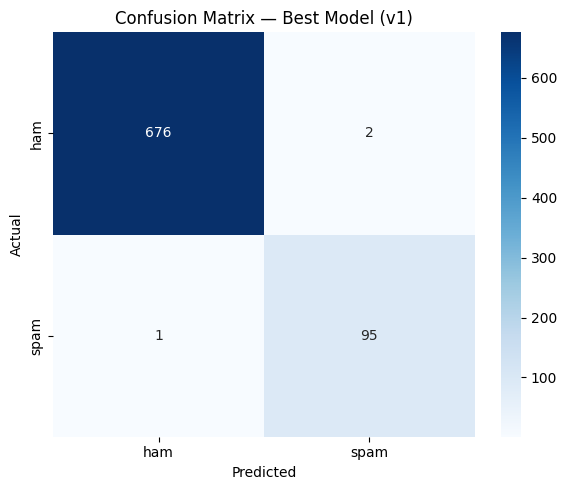

 Confusion matrix saved → /kaggle/working/confusion_matrix.png


In [16]:
test_df_eval = pd.read_csv(f"{DATA_DIR}/test.csv")
label_map    = {"ham": 0, "spam": 1}

y_true, y_pred = [], []
print(f"Running inference on {len(test_df_eval):,} test samples...")

for _, row in test_df_eval.iterrows():
    res = predict(row["text"])
    y_pred.append(label_map[res["label"]])
    y_true.append(int(row["label"]))

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=["ham", "spam"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Best Model ({BEST_VERSION})")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()
print(" Confusion matrix saved → /kaggle/working/confusion_matrix.png")


## Task 10c — Inference Latency Benchmark

In [17]:
samples = [
    "URGENT! Click here for free money!",
    "Hey, are we still meeting tomorrow?",
    "You have been selected for a cash reward. Call now!",
    "Can you please send the updated slides before the meeting?",
    "Congratulations! You've won a lottery prize of £1,000,000.",
    "Let's grab coffee at 3pm — does that work for you?",
]

latencies = []
print(f"{'Sample':<50} {'Latency (ms)':>12}  Label")
print("-" * 72)
for text in samples:
    start  = time.perf_counter()
    result = predict(text)
    ms     = (time.perf_counter() - start) * 1000
    latencies.append(ms)
    print(f"{text[:48]:<50} {ms:>10.2f} ms  [{result['label']}]")

print(f"\nMean latency: {sum(latencies)/len(latencies):.2f} ms")
print(f"Max  latency: {max(latencies):.2f} ms")


Sample                                             Latency (ms)  Label
------------------------------------------------------------------------
URGENT! Click here for free money!                      30.02 ms  [spam]
Hey, are we still meeting tomorrow?                     27.67 ms  [ham]
You have been selected for a cash reward. Call n        33.26 ms  [spam]
Can you please send the updated slides before th        31.18 ms  [ham]
Congratulations! You've won a lottery prize of £        29.45 ms  [spam]
Let's grab coffee at 3pm — does that work for yo        27.72 ms  [ham]

Mean latency: 29.88 ms
Max  latency: 33.26 ms


## Task 11 — Push All Evaluation Outputs to Git *(Owner: G25AIT2113)*

After inference and evaluation are complete, `G25AIT2113` commits all output files to the
repository from their `feature/inference` branch, completing the four-person Git audit trail.


In [18]:
# ── Copy evaluation outputs into repo ─────────────────────────────────────
os.makedirs(f"{REPO_PATH}/outputs", exist_ok=True)

outputs_to_push = {
    "/kaggle/working/confusion_matrix.png" : "outputs/confusion_matrix.png",
    "/kaggle/working/f1_comparison.png"    : "outputs/f1_comparison.png",
    "/kaggle/working/experiment_results.csv": "outputs/experiment_results.csv",
}

for src, rel_dst in outputs_to_push.items():
    if os.path.exists(src):
        shutil.copy(src, f"{REPO_PATH}/{rel_dst}")
        print(f"  Copied {src} → {REPO_PATH}/{rel_dst}")
    else:
        print(f"    Not found (will be present after training): {src}")

# ── Git push from G25AIT2113 ──────────────────────────────────────────────
git_commit_push(
    roll    = "G25AIT2113",
    message = "eval: confusion matrix + latency benchmark + classification report",
    files   = [f"outputs/{Path(v).name}" for v in outputs_to_push.values()],
)

print("\n All evaluation outputs committed by G25AIT2113")


  Copied /kaggle/working/confusion_matrix.png → /kaggle/working/mlops-group36-iitj/outputs/confusion_matrix.png
  Copied /kaggle/working/f1_comparison.png → /kaggle/working/mlops-group36-iitj/outputs/f1_comparison.png
  Copied /kaggle/working/experiment_results.csv → /kaggle/working/mlops-group36-iitj/outputs/experiment_results.csv

───────────────────────────────────────────────────────
  Git push — G25AIT2113  →  branch: feature/inference
  Message : eval: confusion matrix + latency benchmark + classification report [G25AIT2113]
───────────────────────────────────────────────────────
Switched to a new branch 'feature/inference'
[feature/inference 71fba65] eval: confusion matrix + latency benchmark + classification report [G25AIT2113]
 3 files changed, 1 insertion(+), 1 deletion(-)
 rewrite outputs/confusion_matrix.png (99%)
 rewrite outputs/f1_comparison.png (93%)
To https://github.com/g25ait2032-prog/mlops-group36-iitj.git
 + 8dbecb0...71fba65 feature/inference -> feature/inference 

## Task 7 — GitHub Actions Pipeline Status *(Owner: G25AIT2032)*

In [19]:
from IPython.display import Markdown, display

badge_md = """
### MLOps Pipeline Status

![Inference Pipeline](https://github.com/g25ait2032-prog/MLOPS_Group/actions/workflows/inference.yml/badge.svg)

**Docker pull:**
```
docker pull ghcr.io/g25ait2032-prog/mlops_group-inference:latest
docker run -e HF_TOKEN=<your_token> \\
           -e INPUT_TEXT='Free prize winner!' \\
           ghcr.io/g25ait2032-prog/mlops_group-inference:latest
```
"""
display(Markdown(badge_md))


### MLOps Pipeline Status

![Inference Pipeline](https://github.com/g25ait2032-prog/MLOPS_Group/actions/workflows/inference.yml/badge.svg)

**Docker pull:**
```
docker pull ghcr.io/g25ait2032-prog/mlops_group-inference:latest
docker run -e HF_TOKEN=<your_token> \
           -e INPUT_TEXT='Free prize winner!' \
           ghcr.io/g25ait2032-prog/mlops_group-inference:latest
```


## ✅ Submission Checklist

In [20]:
print("=" * 60)
print("  MLOps Group 36 — Submission Checklist")
print("=" * 60)

checklist = [
    ("Task 1",  "GitHub repo: README, .gitignore, LICENSE, develop branch, collaborators"),
    ("Task 2",  "SMS Spam data cleaned, split 70/15/15, CSVs + label maps + manifest saved"),
    ("Task 3",  "DistilBERT tokeniser + model loaded, helpers defined"),
    ("Task 4",  "v1, v2, v3, v4 trained on Kaggle GPU; metrics logged to W&B per run"),
    ("Task 5",  "All model versions pushed to HuggingFace Hub (public)"),
    ("Task 6",  "Dockerfile built; image pushed to GHCR"),
    ("Task 7",  "CI (flake8) + Inference GitHub Actions workflows present"),
    ("Task 8",  "W&B project set to Public; all 4 runs visible; comparison chart saved"),
    ("Task 9",  "Inference setup + model output sanity checks (softmax = 1)"),
    ("Task 10", "Adversarial test cases + full test eval + latency benchmark"),
    ("Task 11", "G25AIT2113 pushes all outputs; full 4-person Git audit trail"),
    ("Report",  "4–5 page PDF with all live links and screenshots"),
]

for task, desc in checklist:
    print(f"  ☑  {task}: {desc}")

print()
print("Links to include in the report PDF:")
print(f"  GitHub : https://github.com/g25ait2032-prog/mlops-group36-iitj")
print(f"  HF v1  : https://huggingface.co/{HF_USERNAME}/MLOPS_group-v1")
print(f"  HF v2  : https://huggingface.co/{HF_USERNAME}/MLOPS_group-v2")
print(f"  HF v3  : https://huggingface.co/{HF_USERNAME}/MLOPS_group-v3")
print(f"  HF v4  : https://huggingface.co/{HF_USERNAME}/MLOPS_group-v4")
print(f"  W&B    : https://wandb.ai/g25ait2032-iit-jodhpur/MLOPS_Group")
print(f"  Docker : ghcr.io/g25ait2032-prog/mlops_group-inference:latest")
print()
print(" Group 36 — All tasks complete. Ready for submission!")


  MLOps Group 36 — Submission Checklist
  ☑  Task 1: GitHub repo: README, .gitignore, LICENSE, develop branch, collaborators
  ☑  Task 2: SMS Spam data cleaned, split 70/15/15, CSVs + label maps + manifest saved
  ☑  Task 3: DistilBERT tokeniser + model loaded, helpers defined
  ☑  Task 4: v1, v2, v3, v4 trained on Kaggle GPU; metrics logged to W&B per run
  ☑  Task 5: All model versions pushed to HuggingFace Hub (public)
  ☑  Task 6: Dockerfile built; image pushed to GHCR
  ☑  Task 7: CI (flake8) + Inference GitHub Actions workflows present
  ☑  Task 8: W&B project set to Public; all 4 runs visible; comparison chart saved
  ☑  Task 9: Inference setup + model output sanity checks (softmax = 1)
  ☑  Task 10: Adversarial test cases + full test eval + latency benchmark
  ☑  Task 11: G25AIT2113 pushes all outputs; full 4-person Git audit trail
  ☑  Report: 4–5 page PDF with all live links and screenshots

Links to include in the report PDF:
  GitHub : https://github.com/g25ait2032-prog/mlo